# 03 Gene and pathway explanations

            Standard Linear SHAP explains the logistic-regression models only.
            It describes which gene inputs push a prediction toward ASD or control,
            relative to the corresponding model's training background. Contributions
            are on a log-odds scale, not a measure of pathway activation.

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display

current = Path.cwd().resolve()
STUDY = next(p for p in (current, *current.parents)
             if (p / "results/published").is_dir())
RESULTS = STUDY / "results/published"

def read_json(relative):
    path = (RESULTS / relative).resolve()
    if not path.is_relative_to(RESULTS.resolve()) or path.suffix != ".json":
        raise ValueError("Only published JSON summaries may be read")
    return json.loads(path.read_text())

def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

print("Review mode: included aggregate results only; no training or participant-table access.")

Review mode: included aggregate results only; no training or participant-table access.


| Measure | Value |
| --- | --- |
| Explained development records | 261 |
| Gene inputs | 17263 |
| Hallmark groups | 50 |
| Gene coverage | 24.4% |
| Absolute gene attribution outside Hallmark | 76.5% |

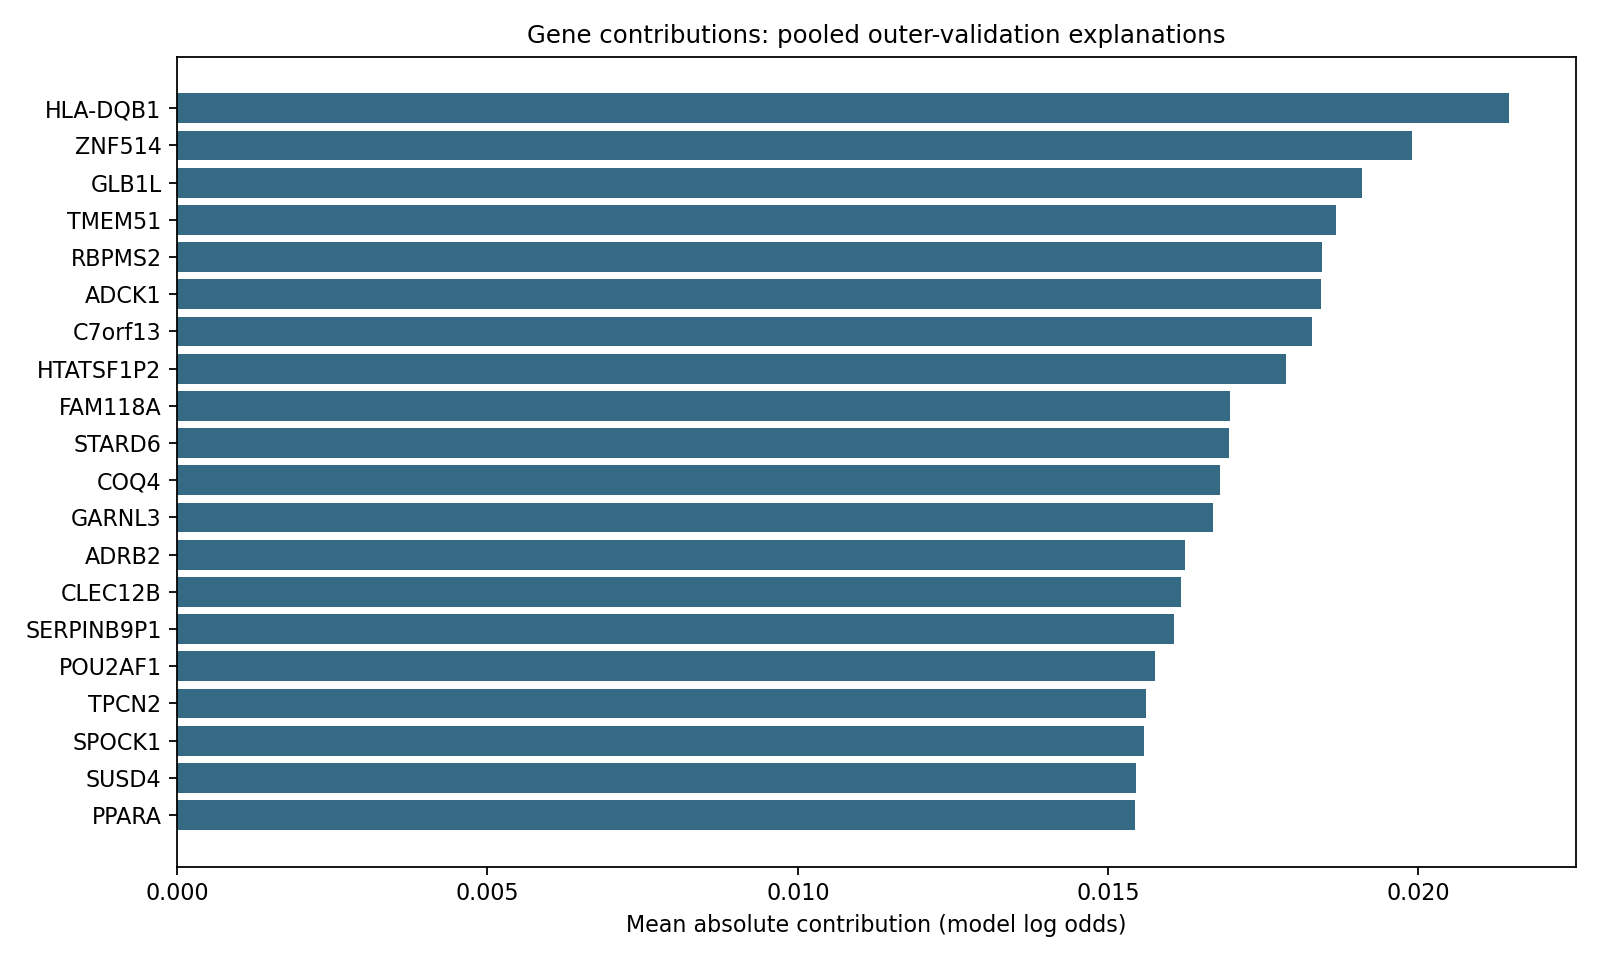

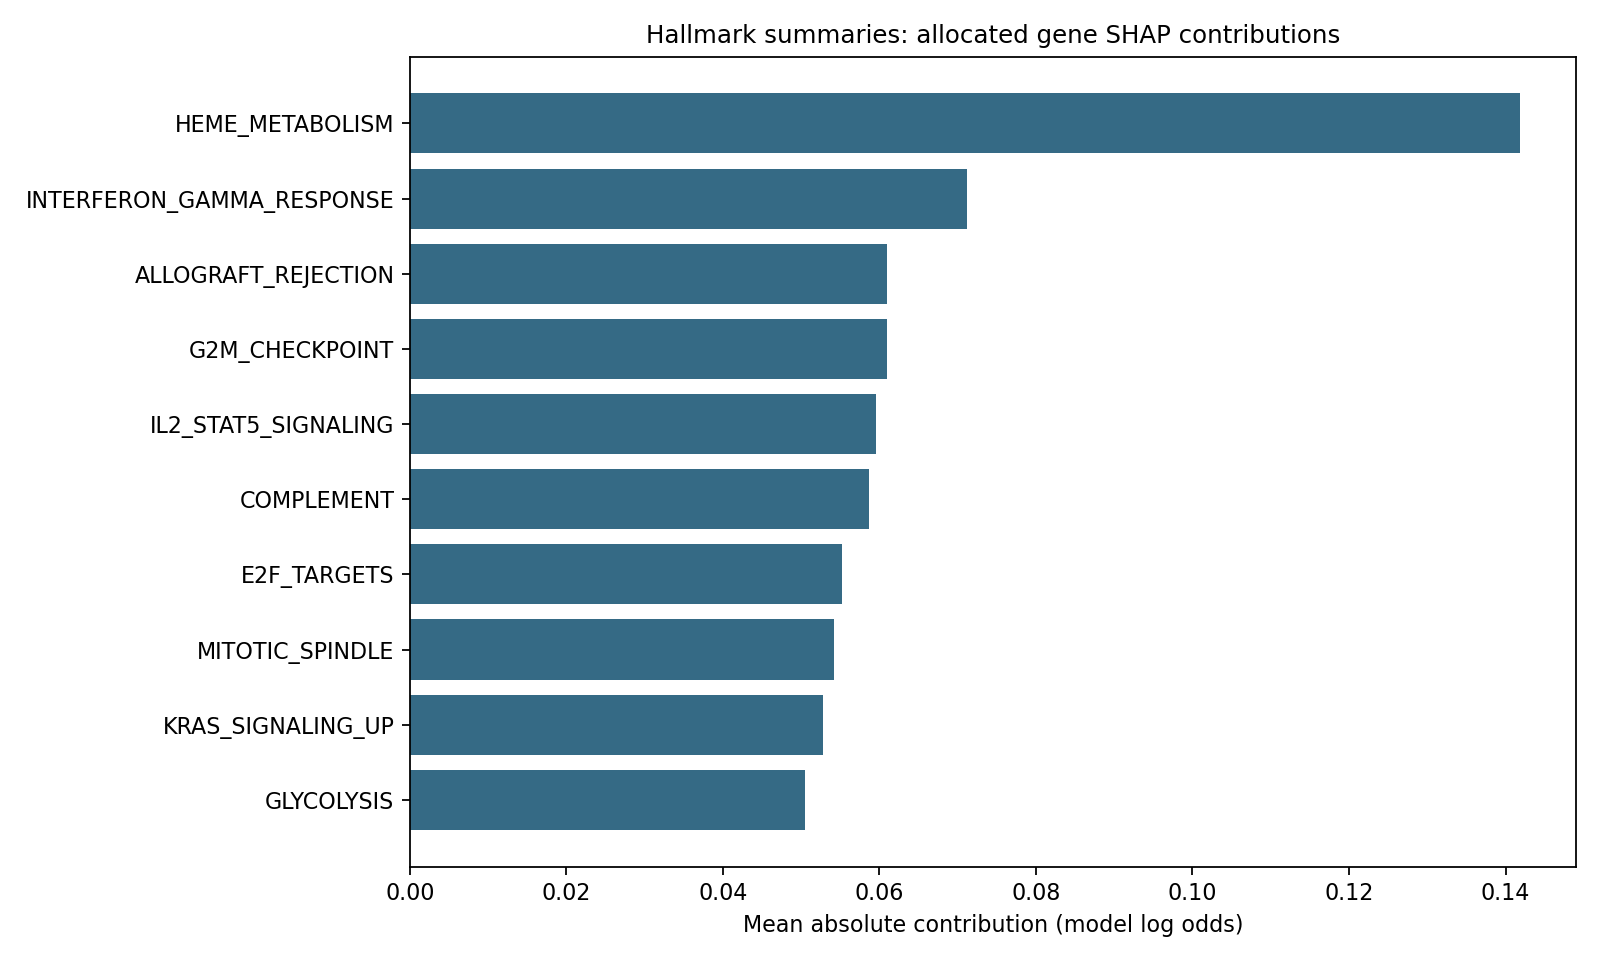

In [2]:
s = read_json("gene_pathway_explanations/summary.json")
table(["Measure", "Value"], [["Explained development records", s["sample_count"]],
    ["Gene inputs", s["gene_count"]], ["Hallmark groups", s["pathway_count"]],
    ["Gene coverage", f'{s["covered_gene_fraction"]:.1%}'],
    ["Absolute gene attribution outside Hallmark", f'{s["unassigned_absolute_gene_share"]:.1%}']])
display(Image(filename=str(RESULTS / "gene_pathway_explanations/figures/gene_importance.png")))
display(Image(filename=str(RESULTS / "gene_pathway_explanations/figures/pathway_importance.png")))

## What grouping does

            Signed gene contributions are added within biological groups. A gene
            occurring in several groups shares its contribution equally among
            them; unassigned contributions remain separate. Opposite signs can
            cancel. This is allocated gene SHAP, not a separately calculated
            pathway Shapley estimator. Predictions do not change.

            Hallmark covers a minority of our genes. Its top groups recur across
            folds, but no clear advantage over matched randomized groups was
            established. Randomization rearranges annotation memberships, not
            patient data. One pooled top-20 gene matches the frozen SFARI reference;
            genetic-risk annotation is not confirmation of a blood biomarker.

            [Explanation report](../../results/published/gene_pathway_explanations/RESULTS.md).
            The next notebook compares broader references using the same gene values.